In [1]:
import pandas as pd
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from tensorflow.keras import layers, Model, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# --- CRITICAL CHANGE: Import ResNet50 instead of VGG16 ---
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input # <--- Specific for ResNet

# --- 1. CONFIGURATION (Identical) ---
TRAIN_DIR = 'archive/Training' 
IMG_SIZE = 224
BATCH_SIZE = 32
N_FOLDS = 5
CLASSES = ['glioma', 'meningioma', 'pituitary', 'notumor']
NUM_CLASSES = 4

In [2]:
# --- 2. PREPARE DATA FRAME ---
filepaths = []
labels = []

if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(f"Directory not found: {TRAIN_DIR}")

classes_list = sorted(os.listdir(TRAIN_DIR))

for class_name in classes_list:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            filepaths.append(os.path.join(class_dir, filename))
            labels.append(class_name)

df = pd.DataFrame({
    'filename': filepaths,
    'class': labels
})

print(f"Found {len(df)} images belonging to {len(classes_list)} classes.")

Found 5712 images belonging to 4 classes.


In [3]:
# --- 3. CUSTOM LAYER (Identical) ---
class ChannelAttention(layers.Layer):
    def __init__(self, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.channels = input_shape[-1]
        self.w = self.add_weight(name='attention_weights',
                                 shape=(self.channels,),
                                 initializer='ones', 
                                 trainable=True)
        super(ChannelAttention, self).build(input_shape)

    def call(self, inputs):
        # 1. Compute attention scores (alpha) using softmax
        alpha = tf.nn.softmax(self.w)
        # 2. Apply attention scores to the input vector
        v_att = inputs * alpha
        return v_att

    def get_config(self):
        config = super(ChannelAttention, self).get_config()
        return config

In [4]:
# --- 4. RESNET50 MODEL BUILDER ---
def build_optimized_resnet_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=4):
    
    # 1. Load ResNet50 Base (Weights = ImageNet, No Top)
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # 2. Fine-Tuning Strategy (Identical Logic)
    # VGG16 Logic: Unfreeze 'block5' (last spatial block)
    # ResNet50 Logic: Unfreeze 'conv5_block...' (last spatial stage)
    
    base_model.trainable = True
    set_trainable = False
    
    for layer in base_model.layers:
        # In ResNet50, the last stage starts with 'conv5_block1'
        if 'conv5_block1' in layer.name: 
            set_trainable = True
        
        if set_trainable:
            layer.trainable = True
        else:
            layer.trainable = False

    # 3. Build the Head (Identical Architecture)
    inputs = base_model.input
    x = base_model.output

    # Attention & Pooling
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = ChannelAttention(name='channel_attention')(x)
    
    # Classification Head
    x = layers.BatchNormalization()(x) 
    x = layers.Dropout(0.4)(x)
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs=inputs, outputs=outputs, name='ResNet50_Optimized')

# Verify the architecture
model_check = build_optimized_resnet_model()
model_check.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step 



Model: "ResNet50_Optimized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 24,124,548 (92.03 MB)

 Trainable params: 15,508,228 (59.16 MB)

 Non-trainable params: 8,616,320 (32.87 MB)

In [5]:
# --- 5. K-FOLD TRAINING LOOP ---
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# Augmentation (Identical params, but using ResNet Preprocessing)
train_datagen_args = dict(
    preprocessing_function=preprocess_input,  # <--- ResNet specific      
    rotation_range=40,       
    width_shift_range=0.2,   
    height_shift_range=0.2,  
    zoom_range=0.2,          
    horizontal_flip=True,    
    fill_mode='nearest'
)

val_datagen_args = dict(
    preprocessing_function=preprocess_input   # <--- ResNet specific
)

# Storage for results
acc_per_fold = []
loss_per_fold = []
all_y_true = []
all_y_pred = []
fold_accuracies_raw = []
fold_no = 1

for train_index, val_index in kf.split(df):
    print(f"\n--- Training Fold {fold_no} / {N_FOLDS} ---")
    
    # Split Data
    train_df = df.iloc[train_index]
    val_df = df.iloc[val_index]
    
    # Create Generators
    train_datagen = ImageDataGenerator(**train_datagen_args)
    val_datagen = ImageDataGenerator(**val_datagen_args)
    
    train_generator = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col='filename',
        y_col='class',
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True
    )
    
    val_generator = val_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col='filename',
        y_col='class',
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False 
    )
    
    # Build Model
    model = build_optimized_resnet_model()
    
    # Compile (Identical LR and Optimizer)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-5), 
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks (Identical)
    early_stop = EarlyStopping(
        monitor='val_loss', 
        patience=8, 
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.2, 
        patience=4, 
        min_lr=1e-7,
        verbose=1
    )
    
    # Train
    history = model.fit(
        train_generator,
        epochs=50, 
        validation_data=val_generator,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    # Evaluate
    scores = model.evaluate(val_generator, verbose=0)
    print(f"Score for Fold {fold_no}: {model.metrics_names[0]}={scores[0]}; {model.metrics_names[1]}={scores[1]*100}%")
    
    acc_per_fold.append(scores[1] * 100)
    loss_per_fold.append(scores[0])
    fold_accuracies_raw.append(scores[1])
    
    # Predictions for overall confusion matrix
    val_generator.reset()
    preds = model.predict(val_generator, verbose=0)
    y_pred_classes = np.argmax(preds, axis=1)
    y_true_classes = val_generator.classes
    
    all_y_true.extend(y_true_classes)
    all_y_pred.extend(y_pred_classes)
    
    # Save the best model from this fold
    model.save(f"ResNet50_Fold{fold_no}_Best.h5")
    
    fold_no += 1

# Final Summary
print("\n--- Cross-Validation Results ---")
print(f"Average Accuracy: {np.mean(acc_per_fold):.2f}% (+/- {np.std(acc_per_fold):.2f}%)")


--- Training Fold 1 / 5 ---
Found 4569 validated image filenames belonging to 4 classes.
Found 1143 validated image filenames belonging to 4 classes.


C:\Users\VICKY\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.6041 - loss: 1.0284 - val_accuracy: 0.7069 - val_loss: 1.3759 - learning_rate: 1.0000e-05
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.8225 - loss: 0.5526 - val_accuracy: 0.8478 - val_loss: 1.3082 - learning_rate: 1.0000e-05
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.8722 - loss: 0.3900 - val_accuracy: 0.8810 - val_loss: 1.0700 - learning_rate: 1.0000e-05
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.8958 - loss: 0.3100 - val_accuracy: 0.9116 - val_loss: 0.5622 - learning_rate: 1.0000e-05
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.9131 - loss: 0.2503 - val_accuracy: 0.9256 - val_loss: 0.2527 - learning_rate: 1.0000e-05
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.9278 - loss: 0.2138 - val_accuracy: 0.9344 - val_loss: 0.1837 - learning_rate: 1.0000e-05
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - acc


--- Training Fold 2 / 5 ---
Found 4569 validated image filenames belonging to 4 classes.
Found 1143 validated image filenames belonging to 4 classes.


C:\Users\VICKY\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


...

Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.6326 - loss: 1.0236 - val_accuracy: 0.7032 - val_loss: 1.3766 - learning_rate: 1.0000e-05
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.8335 - loss: 0.5537 - val_accuracy: 0.8214 - val_loss: 1.3152 - learning_rate: 1.0000e-05
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.8711 - loss: 0.3960 - val_accuracy: 0.8809 - val_loss: 1.0930 - learning_rate: 1.0000e-05
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.8958 - loss: 0.3136 - val_accuracy: 0.9124 - val_loss: 0.6094 - learning_rate: 1.0000e-05
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.9136 - loss: 0.2618 - val_accuracy: 0.9133 - val_loss: 0.2867 - learning_rate: 1.0000e-05
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.9328 - loss: 0.2140 - val_accuracy: 0.9308 - val_loss: 0.1988 - learning_rate: 1.0000e-05
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - acc


--- Training Fold 5 / 5 ---
Found 4570 validated image filenames belonging to 4 classes.
Found 1142 validated image filenames belonging to 4 classes.


C:\Users\VICKY\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.6416 - loss: 0.9921 - val_accuracy: 0.7758 - val_loss: 1.3757 - learning_rate: 1.0000e-05
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.8304 - loss: 0.5505 - val_accuracy: 0.8722 - val_loss: 1.3127 - learning_rate: 1.0000e-05
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.8729 - loss: 0.3831 - val_accuracy: 0.9089 - val_loss: 1.0834 - learning_rate: 1.0000e-05
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.8985 - loss: 0.3069 - val_accuracy: 0.9098 - val_loss: 0.5907 - learning_rate: 1.0000e-05
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.9158 - loss: 0.2546 - val_accuracy: 0.9264 - val_loss: 0.2481 - learning_rate: 1.0000e-05
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.9265 - loss: 0.2164 - val_accuracy: 0.9343 - val_loss: 0.1795 - learning_rate: 1.0000e-05
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - acc


--- Cross-Validation Results ---
Average Accuracy: 97.71% (+/- 0.39%)


ResNet50 Data saved.


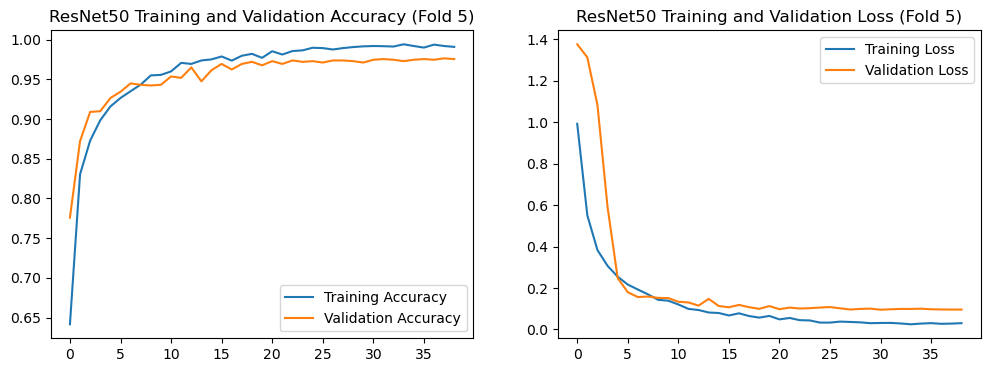

In [6]:
# --- 6. SAVE RESULTS & PLOT ---

# Save detailed predictions
df_detailed = pd.DataFrame({
    'y_true': all_y_true, 
    'y_pred': all_y_pred
})
df_detailed.to_csv('ResNet50_5fold_Detailed.csv', index=False)

# Save fold scores
df_scores = pd.DataFrame({
    'Fold': range(1, len(fold_accuracies_raw) + 1),
    'Accuracy': fold_accuracies_raw
})
df_scores.to_csv('ResNet50_5fold_Fold_Scores.csv', index=False)

print("ResNet50 Data saved.")

# Visualize Training History (Last Fold Only as example)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('ResNet50 Training and Validation Accuracy (Fold 5)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('ResNet50 Training and Validation Loss (Fold 5)')
plt.show()

Found 1311 TEST images belonging to 4 classes.
Found 1311 validated image filenames belonging to 4 classes.

--- Starting Ensemble Prediction using all 5 ResNet50 models ---
Loading ResNet50_Fold1_Best.h5...


C:\Users\VICKY\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Loading ResNet50_Fold2_Best.h5...


Loading ResNet50_Fold3_Best.h5...


Loading ResNet50_Fold4_Best.h5...


Loading ResNet50_Fold5_Best.h5...



--- Test Set Classification Report ---
              precision    recall  f1-score   support

      glioma       0.99      0.98      0.98       300
  meningioma       0.98      0.98      0.98       306
     notumor       1.00      1.00      1.00       405
   pituitary       0.98      1.00      0.99       300

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



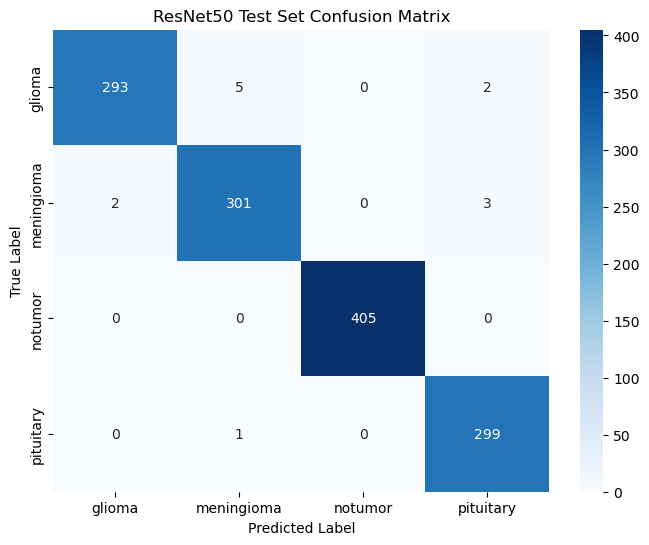

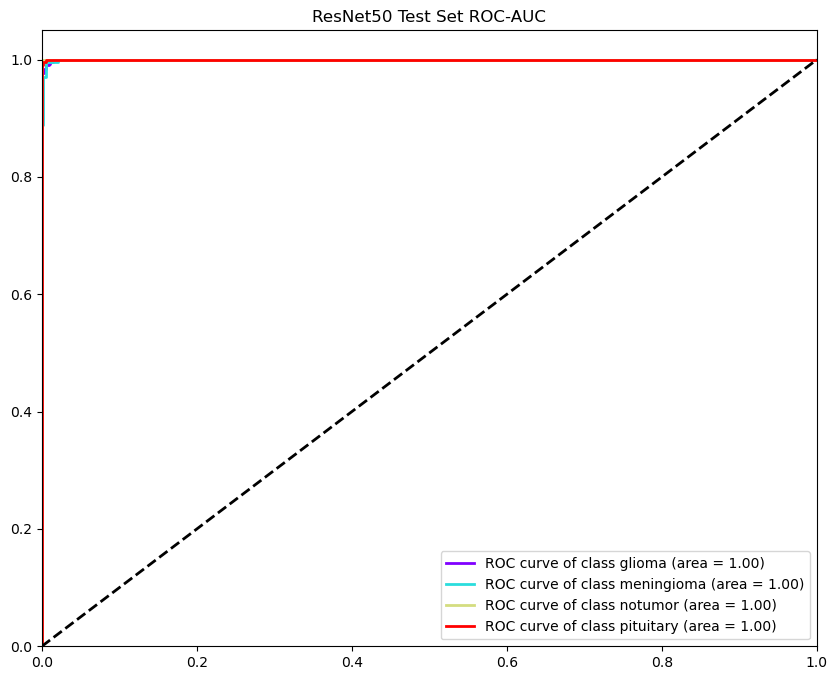


Saved 'ResNet50_Wilcoxon_Data.csv' for statistical comparison.

--- Calculating 95% Confidence Intervals (Bootstrapping 1000 iterations) ---
ACCURACY: 0.9901 (95% CI: 0.9847 - 0.9947)
AUC: 0.9999 (95% CI: 0.9997 - 1.0000)
F1: 0.9901 (95% CI: 0.9847 - 0.9947)


In [7]:
# --- 7. INDEPENDENT TEST SET EVALUATION (ENSEMBLE) ---
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, f1_score, roc_auc_score
from tensorflow.keras.models import load_model
from sklearn.utils import resample
import seaborn as sns

# 1. LOAD TEST DATA
TEST_DIR = 'archive/Testing' 
test_filepaths = []
test_labels = []

if not os.path.exists(TEST_DIR):
    print(f"WARNING: Test directory '{TEST_DIR}' not found. Please check your dataset path.")
else:
    test_classes = sorted(os.listdir(TEST_DIR))
    for class_name in test_classes:
        class_dir = os.path.join(TEST_DIR, class_name)
        if os.path.isdir(class_dir):
            for filename in os.listdir(class_dir):
                test_filepaths.append(os.path.join(class_dir, filename))
                test_labels.append(class_name)

    test_df = pd.DataFrame({
        'filename': test_filepaths,
        'class': test_labels
    })

    print(f"Found {len(test_df)} TEST images belonging to {len(test_classes)} classes.")

    # 2. CREATE TEST GENERATOR
    # Critical: Use ResNet Preprocessing
    test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input 
    )

    test_gen = test_datagen.flow_from_dataframe(
        test_df,
        x_col='filename',
        y_col='class',
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False  # <--- MUST BE FALSE to align predictions with labels
    )

    # 3. ENSEMBLE PREDICTION (Average of 5 Folds)
    print(f"\n--- Starting Ensemble Prediction using all {N_FOLDS} ResNet50 models ---")
    
    # Initialize empty array for summing probabilities
    ensemble_sum = np.zeros((len(test_df), NUM_CLASSES))

    for fold_idx in range(1, N_FOLDS + 1):
        # Load the ResNet model we saved in the previous block
        model_filename = f"ResNet50_Fold{fold_idx}_Best.h5"
        
        if os.path.exists(model_filename):
            print(f"Loading {model_filename}...")
            # Must specify ChannelAttention because it's a custom layer
            fold_model = load_model(model_filename, custom_objects={'ChannelAttention': ChannelAttention})
            
            # Predict
            preds = fold_model.predict(test_gen, verbose=0)
            ensemble_sum += preds
        else:
            print(f"Warning: {model_filename} not found. Skipping.")

    # Average the predictions
    test_predictions = ensemble_sum / N_FOLDS
    
    # Get Class Indices
    test_y_pred_indices = np.argmax(test_predictions, axis=1)
    test_y_true_indices = test_gen.classes
    test_class_labels = list(test_gen.class_indices.keys())

    # 4. EVALUATION REPORTS
    print("\n--- Test Set Classification Report ---")
    print(classification_report(test_y_true_indices, test_y_pred_indices, target_names=test_class_labels))

    # Confusion Matrix
    test_cm = confusion_matrix(test_y_true_indices, test_y_pred_indices)
    plt.figure(figsize=(8, 6))
    sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=test_class_labels, yticklabels=test_class_labels)
    plt.title('ResNet50 Test Set Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # ROC-AUC Curve
    n_classes = len(test_class_labels)
    test_y_true_onehot = tf.keras.utils.to_categorical(test_y_true_indices, num_classes=n_classes)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    plt.figure(figsize=(10, 8))
    colors = plt.cm.rainbow(np.linspace(0, 1, n_classes))
    
    for i, color in zip(range(n_classes), colors):
        fpr[i], tpr[i], _ = roc_curve(test_y_true_onehot[:, i], test_predictions[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of class {0} (area = {1:0.2f})'.format(test_class_labels[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.title('ResNet50 Test Set ROC-AUC')
    plt.legend(loc="lower right")
    plt.show()

    # 5. SAVE DATA FOR STATISTICAL COMPARISON (WILCOXON)
    # Get probability of the TRUE class
    prob_of_true_class = [pred[true_idx] for pred, true_idx in zip(test_predictions, test_y_true_indices)]
    is_correct = (test_y_pred_indices == test_y_true_indices).astype(int)

    wilcoxon_df = pd.DataFrame({
        'filename': test_gen.filenames,
        'y_true': test_y_true_indices,
        'y_pred': test_y_pred_indices,
        'prob_true_class': prob_of_true_class, 
        'is_correct': is_correct
    })
    
    wilcoxon_df.to_csv('ResNet50_Wilcoxon_Data.csv', index=False)
    print("\nSaved 'ResNet50_Wilcoxon_Data.csv' for statistical comparison.")

    # 6. 95% CONFIDENCE INTERVALS (BOOTSTRAPPING)
    print("\n--- Calculating 95% Confidence Intervals (Bootstrapping 1000 iterations) ---")
    n_iterations = 1000
    alpha = 0.95
    p = ((1.0 - alpha) / 2.0) * 100
    q = (alpha + ((1.0 - alpha) / 2.0)) * 100

    stats = {'accuracy': [], 'auc': [], 'f1': []}
    
    # Pre-convert to numpy for speed
    y_true_all = np.array(test_y_true_indices)
    y_pred_all = np.array(test_y_pred_indices)
    y_proba_all = np.array(test_predictions)

    for i in range(n_iterations):
        indices = resample(np.arange(len(y_true_all)), replace=True)
        
        y_true_boot = y_true_all[indices]
        y_pred_boot = y_pred_all[indices]
        y_proba_boot = y_proba_all[indices]
        
        acc = accuracy_score(y_true_boot, y_pred_boot)
        f1 = f1_score(y_true_boot, y_pred_boot, average='weighted')
        
        try:
            # Re-encode for AUC
            y_true_boot_onehot = tf.keras.utils.to_categorical(y_true_boot, num_classes=n_classes)
            auc_score = roc_auc_score(y_true_boot_onehot, y_proba_boot, multi_class='ovr', average='weighted')
        except ValueError:
            auc_score = np.nan

        stats['accuracy'].append(acc)
        stats['f1'].append(f1)
        if not np.isnan(auc_score):
            stats['auc'].append(auc_score)

    for metric_name, values in stats.items():
        values.sort()
        lower = np.percentile(values, p)
        upper = np.percentile(values, q)
        mean_val = np.mean(values)
        print(f"{metric_name.upper()}: {mean_val:.4f} (95% CI: {lower:.4f} - {upper:.4f})")